# <font color= #83eac2 >**03 - Entrenamiento y Evaluación** </font>

---

## <font color = #84c4da >**1. Importar bibliotecas y cargar datos** </font>
---

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Modelos
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

# Evaluación
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, 
                             balanced_accuracy_score, ConfusionMatrixDisplay, f1_score, recall_score, precision_score)

# Guardar Modelo
import pickle

### **Cargar datos**

In [83]:
train = pd.read_csv('../data/processed/train_processed.csv')
test = pd.read_csv('../data/processed/test_processed.csv')

# Separar features y target
X_train = train.drop(columns='Patient Satisfaction')
y_train = train['Patient Satisfaction']

X_test = test.drop(columns='Patient Satisfaction')
y_test = test['Patient Satisfaction']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print("="*30)
print(f"Distribución target en train:")
print(y_train.value_counts().sort_index().round(3))

X_train: (4000, 9)
X_test:  (1000, 9)
Distribución target en train:
Patient Satisfaction
1    1230
2     484
3     699
4    1143
5     444
Name: count, dtype: int64


## <font color = #84c4da >**2. Definición de variables** </font>
---

In [84]:
# Variables numéricas: se escalarán con StandardScaler
numericas = [
    'Nurse-to-Patient Ratio',
    'Time to Registration (min)',
    'Time to Triage (min)',
    'Time to Medical Professional (min)'
]

# Variables ordinales: tienen orden natural.
ordinales = [
    'Urgency Level',      # Low , Medium , High , Critical
    'Time of Day',        # Early Morning, Late Morning , Afternoon , Evening , Night
    'categoria_espera'    # 1 , 2 , 3 , 4
]

# Variables nominales: sin orden, se aplicará OneHotEncoder
nominales = [
    'Season',          # Summer, Fall, Winter, Spring
    'Day of Week'      # Tuesday, Sunday, Monday, Saturday, Thursday, Friday, Wednesday
]

print(f"Numéricas: {len(numericas)}")
print(f"Ordinales: {len(ordinales)}")
print(f"Nominales: {len(nominales)}")
print(f"Total features: {len(numericas) + len(ordinales) + len(nominales)}")

Numéricas: 4
Ordinales: 3
Nominales: 2
Total features: 9


## <font color = #84c4da >**3. Preprocesamiento - ColumnTransformer** </font>

In [85]:
# Orden para OrdinalEncoder
urgency_order = [['Low', 'Medium', 'High', 'Critical']]
time_order = [['Early Morning', 'Late Morning', 'Afternoon', 'Evening', 'Night']]
espera_order = [[1, 2, 3, 4]]

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numericas),
    ('ord', OrdinalEncoder(categories=urgency_order + time_order + espera_order), ordinales),
    ('nom', OneHotEncoder(drop='first', sparse_output=False), nominales)
])

## <font color = #84c4da >**4. Entrenamiento inicial — Pipeline por modelo** </font>
---

### **Entrenamos cada modelo con parámetros base y validación cruzada para identificar los 3 mejores candidatos antes del ajuste fino.**

In [108]:
pipeline_lr = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',
        solver='saga',
        l1_ratio=1,
        random_state=42))
])

pipeline_svm = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', SVC(
        class_weight='balanced',
        probability=True,
        random_state=42))
])

pipeline_dt = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', RandomForestClassifier(
        class_weight='balanced',
        n_jobs=-1,
        random_state=42))
])

pipeline_gb = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', GradientBoostingClassifier(
        random_state=42))
])

pipeline_cat = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42))
])

### **Comparación con Cross Validation**

In [109]:
modelos = {
    'Logistic Regression': pipeline_lr,
    'SVM'                : pipeline_svm,
    'Decision Tree'      : pipeline_dt,
    'Random Forest'      : pipeline_rf,
    'GradientBoosting'   : pipeline_gb,
    'CatBoost'           : pipeline_cat
}

resultados_cv = []

for nombre, pipeline in modelos.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5,
        scoring='balanced_accuracy',
        n_jobs=-1
    )
    resultados_cv.append({
        'Modelo': nombre,
        'Media CV': scores.mean(),
        'Std CV': scores.std()
    })


### **Resultados**

In [110]:
resultados_cv_df = pd.DataFrame(resultados_cv).sort_values('Media CV', ascending=False)
resultados_cv_df

,Modelo,Media CV,Std CV
0,Logistic Regression,0.783308,0.013926
1,SVM,0.782812,0.011428
5,CatBoost,0.750120,0.011261
4,GradientBoosting,0.733474,0.014696
3,Random Forest,0.728534,0.014096
2,Decision Tree,0.674950,0.020345


SVM y Logistic Regression están muy cerca, cualquiera puede ganar en el ajuste fino.<br>
CatBoost está a 0.03 de distancia, también tiene margen de mejora con ajuste fino <br>
Std baja en los 3, podria segurase que son modelos estables, no hay mucha varianza entre folds.

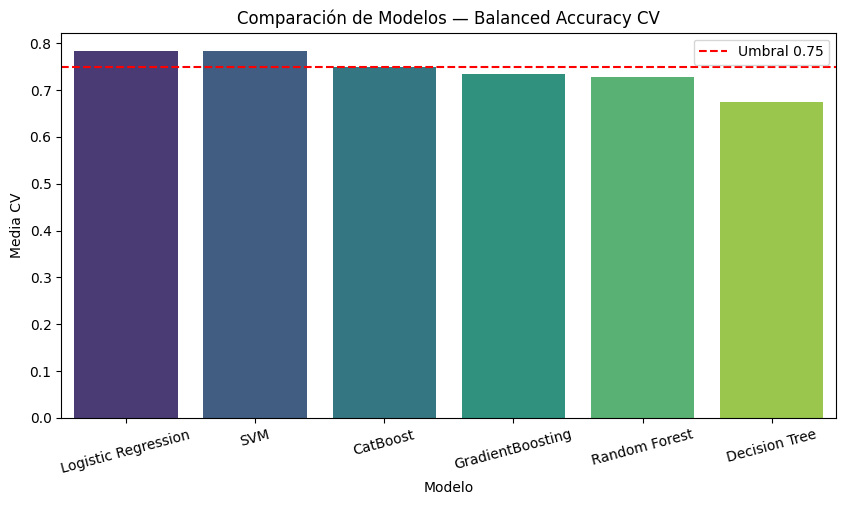

In [111]:
plt.figure(figsize=(10, 5))
sns.barplot(data=resultados_cv_df, x='Modelo', y='Media CV', palette='viridis', hue= 'Modelo', legend= False)
plt.axhline(y=0.75, color='red', linestyle='--', label='Umbral 0.75')
plt.title('Comparación de Modelos — Balanced Accuracy CV')
plt.xticks(rotation=15)
plt.legend()
plt.show()

## <font color = #84c4da >**5. Ajuste de Hiperparámetros - Top 3 Modelos** </font>
---

### **Aplicamos GridSearchCV individualmente sobre los 3 mejores modelos para encontrar los hiperparámetros óptimos de cada uno.**

### **5.1 Logistic Regression**

In [112]:
lr_params = {
    'modelo__C': [0.01, 0.1, 1, 10, 100],
    'modelo__l1_ratio': [0, 0.5, 1], 
    'modelo__solver': ['saga']
}

gs_lr = GridSearchCV(
    pipeline_lr,
    lr_params,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

gs_lr.fit(X_train, y_train)

print(f"Mejor score LR: {gs_lr.best_score_:.4f}")
print(f"Mejores parámetros: {gs_lr.best_params_}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Mejor score LR: 0.7844
Mejores parámetros: {'modelo__C': 0.1, 'modelo__l1_ratio': 1, 'modelo__solver': 'saga'}


### **5.2 SVM**

In [114]:
svm_params = {
    'modelo__kernel': ['rbf', 'linear'],
    'modelo__C': [0.1, 1, 10, 100]
}

gs_svm = GridSearchCV(
    pipeline_svm,
    svm_params,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

gs_svm.fit(X_train, y_train)

print(f"Mejor score SVM: {gs_svm.best_score_}")
print(f"Mejores parámetros: {gs_svm.best_params_}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejor score SVM: 0.7828123687806622
Mejores parámetros: {'modelo__C': 1, 'modelo__kernel': 'rbf'}


### **5.3 CatBoost**

In [115]:
cat_params = {
    'modelo__iterations': [200, 300, 400],
    'modelo__learning_rate': [0.01, 0.05, 0.1],
    'modelo__depth': [3, 4, 5],
    'modelo__l2_leaf_reg': [1, 3, 5]
}

gs_cat = GridSearchCV(
    pipeline_cat,
    cat_params,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)

gs_cat.fit(X_train, y_train)

print(f"Mejor score CatBoost: {gs_cat.best_score_}")
print(f"Mejores parámetros: {gs_cat.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Mejor score CatBoost: 0.7907916064855451
Mejores parámetros: {'modelo__depth': 3, 'modelo__iterations': 300, 'modelo__l2_leaf_reg': 1, 'modelo__learning_rate': 0.01}


### **Resumen ajuste fino — Top 3 modelos**

| Modelo | Mejor Score CV | C | Otros parámetros |
|---|---|---|---|
| Logistic Regression | 0.7844 | 0.1 | l1_ratio=1, solver=saga |
| SVM | 0.7828 | 1 | kernel=rbf |
| CatBoost | **0.7908** ⭐ | - | depth=3, iterations=300, l2_leaf_reg=1, learning_rate=0.01 |

CatBoost obtiene el mejor score en validación cruzada. 
Se evaluarán los 3 modelos sobre X_test para confirmar cuál generaliza mejor.

## <font color = #84c4da >**6. Evaluación final sobre X_test - Top 3 modelos** </font>

In [119]:
top3 = {
    'Logistic Regression': gs_lr.best_estimator_,
    'SVM': gs_svm.best_estimator_,
    'CatBoost': gs_cat.best_estimator_
}

resultados_test = []

for nombre, modelo in top3.items():
    y_pred = modelo.predict(X_test)
    resultados_test.append({
        'Modelo': nombre,
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'Recall Macro': recall_score(y_test, y_pred, average='macro'),
        'Precision Macro': precision_score(y_test, y_pred, average='macro')
    })

resultados_test_df = pd.DataFrame(resultados_test).sort_values('Balanced Accuracy', ascending=False)
resultados_test_df

,Modelo,Balanced Accuracy,F1 Macro,Recall Macro,Precision Macro
0,Logistic Regression,0.809666,0.765873,0.809666,0.763797
1,SVM,0.797861,0.756511,0.797861,0.753498
2,CatBoost,0.796215,0.750404,0.796215,0.751161


## <font color = #84c4da >**7. Selección del Modelo Final** </font>

| Modelo | Score CV | Balanced Accuracy Test | F1 Macro | Recall Macro | Precision Macro |
|---|---|---|---|---|---|
|**Logistic Regression** | 0.7844 | **0.8097** ⭐ | **0.7659** | **0.8097** | **0.7638** |
| SVM | 0.7828 | 0.7979 | 0.7565 | 0.7979 | 0.7535 |
| CatBoost | 0.7908 | 0.7962 | 0.7504 | 0.7962 | 0.7512 |

### <font color= #e19a94>***Modelo seleccionado: Logistic Regression***</font><br>

Aunque CatBoost obtuvo el mejor score en validación cruzada (0.7908),
Logistic Regression generaliza mejor sobre datos nuevos (0.8097 en X_test).
Esto indica que CatBoost presentó leve overfitting al conjunto de entrenamiento.

La relación lineal fuerte entre los tiempos de espera y la satisfacción 
(-0.80 a -0.86 de correlación) explica por qué un modelo lineal como 
Logistic Regression funciona tan bien en este dataset.

In [120]:
# Modelo final
final_model = gs_lr.best_estimator_

# Predicciones
y_pred = final_model.predict(X_test)

# Métricas detalladas
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.99      0.94      0.96       308
           2       0.71      0.88      0.79       121
           3       0.74      0.79      0.77       174
           4       0.87      0.53      0.66       286
           5       0.51      0.90      0.65       111

    accuracy                           0.79      1000
   macro avg       0.76      0.81      0.77      1000
weighted avg       0.82      0.79      0.79      1000



## <font color = #84c4da >**8. Evaluación detallada — Modelo Final (Logistic Regression)** </font>

### Classification Report

| Clase | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| 1 (Muy insatisfecho) | 0.99 | 0.94 | 0.96 | 308 |
| 2 | 0.71 | 0.88 | 0.79 | 121 |
| 3 | 0.74 | 0.79 | 0.77 | 174 |
| 4 | 0.87 | 0.53 | 0.66 | 286 |
| 5 (Muy satisfecho) | 0.51 | 0.90 | 0.65 | 111 |
| **Macro avg** | **0.76** | **0.81** | **0.77** | 1000 |


### Análisis por clase

- **Clase 1** → el modelo detecta casi perfectamente a los pacientes muy insatisfechos (recall 0.94, precision 0.99) 
- **Clase 2** → buen recall (0.88), detecta bien los pacientes con satisfacción baja
- **Clase 3** → rendimiento equilibrado (0.79 recall, 0.74 precision) 
- **Clase 4** → precision alta (0.87) pero recall bajo (0.53), el modelo pierde muchos pacientes de esta clase
- **Clase 5** → precision baja (0.51) pero recall alto (0.90), detecta bien los muy satisfechos pero con muchos falsos positivos


### **Conclusión**

El modelo funciona muy bien en los extremos (clases 1 y 5) pero tiene 
más dificultad con las clases intermedias (4 y 5), lo cual es esperable 
en problemas de satisfacción donde la frontera entre niveles adyacentes 
es difusa.

### <font color= #e19a94>***Accuracy: 0.79 — Balanced Accuracy: 0.81***</font><br>

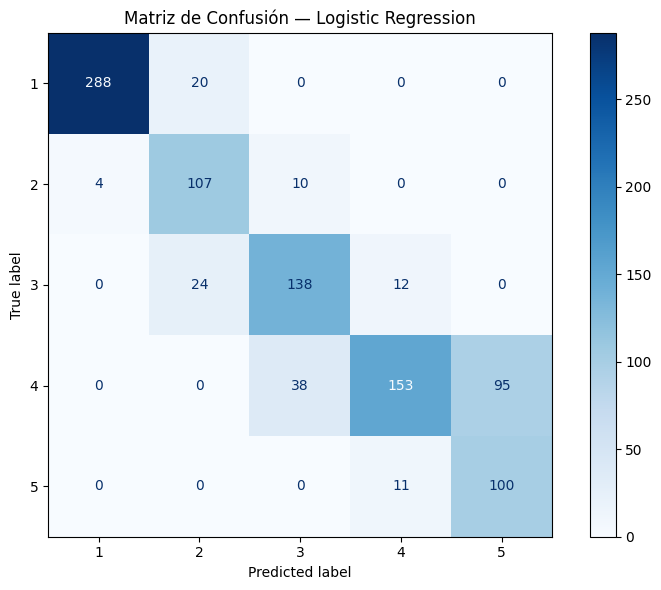

In [121]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[1, 2, 3, 4, 5],
    cmap='Blues',
    ax=ax
)
ax.set_title('Matriz de Confusión — Logistic Regression')
plt.tight_layout()
plt.show()

### **Matriz de Confusión**

**Aciertos por clase (diagonal principal):**
- Clase 1: 288/308 → 93.5% ✅
- Clase 2: 107/121 → 88.4% ✅
- Clase 3: 138/174 → 79.3% ✅
- Clase 4: 153/286 → 53.5% ⚠️
- Clase 5: 100/111 → 90.1% ✅

**Errores más frecuentes:**
- 95 pacientes de clase 4 fueron predichos como clase 5
- 38 pacientes de clase 4 fueron predichos como clase 3
- 24 pacientes de clase 3 fueron predichos como clase 2
- 20 pacientes de clase 1 fueron predichos como clase 2

**Observaciones:**
- El modelo **nunca confunde clases extremas**, es decir no predice clase 5 cuando es clase 1 ni viceversa.
- Los errores ocurren siempre entre **clases adyacentes** — confunde  4 con 5, 3 con 2, etc. Esto es esperable ya que la frontera entre 
  niveles de satisfacción consecutivos es difusa.
- La clase 4 es la más difícil de predecir, se confunde frecuentemente con clase 5 (95 casos)

## <font color = #84c4da >**9. Guardar modelos** </font>

In [123]:
# Guardar modelos entrenados individualmente
modelos_guardar = {
    'trained_model_1_lr': gs_lr.best_estimator_,   # Logistic Regression
    'trained_model_2_svm': gs_svm.best_estimator_, # SVM
    'trained_model_3_dt': pipeline_dt,             # Decision Tree
    'trained_model_4_rf': pipeline_rf,             # Random Forest
    'trained_model_5_gb': pipeline_gb,             # GradientBoosting
    'trained_model_6_cat': gs_cat.best_estimator_  # CatBoost
}

for nombre, modelo in modelos_guardar.items():
    with open(f'../models/{nombre}.pkl', 'wb') as f:
        pickle.dump(modelo, f)
    print(f"Guardado: ../models/{nombre}.pkl")

Guardado: ../models/trained_model_1_lr.pkl
Guardado: ../models/trained_model_2_svm.pkl
Guardado: ../models/trained_model_3_dt.pkl
Guardado: ../models/trained_model_4_rf.pkl
Guardado: ../models/trained_model_5_gb.pkl
Guardado: ../models/trained_model_6_cat.pkl


In [124]:
# Guardar modelo final
with open('../models/final_model.pkl', 'wb') as f:
    pickle.dump(gs_lr.best_estimator_, f)

print("\nModelo final guardado: ../models/final_model.pkl")


Modelo final guardado: ../models/final_model.pkl
